In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [203]:
X, y = make_blobs(n_samples=500, centers=3, cluster_std=0.60,random_state=42)

In [204]:
df = pd.DataFrame(X,columns=['Feature1','Feature2'])

In [205]:
df.head()

,Feature1,Feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [206]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [207]:
wcss = []
K_range = range(1,11)

In [208]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [209]:
wcss

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

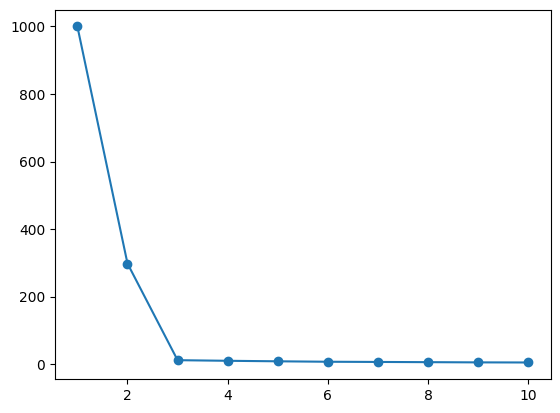

In [210]:
plt.plot(K_range,wcss,marker='o')

# In figure you can see point 3 is the best point.

# Now making final K-means cluster because
# because upper K-means cluster have differnt dynamic parameters

In [211]:
# Now as we see best point is 3 so use use cluster=3.
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [212]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [213]:
kmeans_final

KMeans(n_clusters=3, random_state=42)

In [214]:
df['cluster'] = cluster_labels

In [215]:
df['cluster']

,cluster
0,1
1,0
2,0
3,2
4,0
...,...
495,1
496,2
497,0
498,1


<Axes: xlabel='Feature1', ylabel='Feature2'>

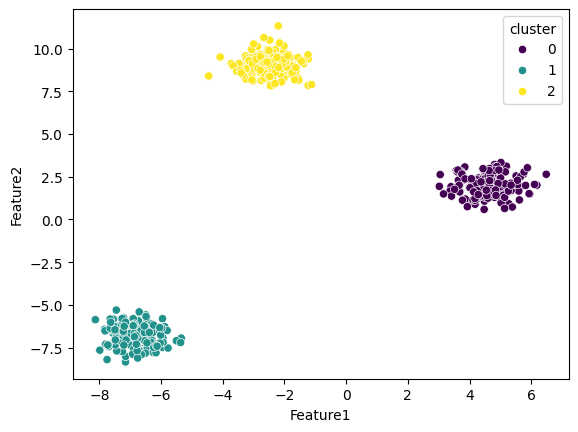

In [216]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['cluster'],
                palette='viridis')

In [217]:
from sklearn.datasets import make_moons

In [218]:
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [219]:
from sklearn.cluster import KMeans, DBSCAN

In [220]:
df = pd.DataFrame(X, columns = ['Features1','Features2'])

In [221]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [222]:
kmeans = KMeans(n_clusters=2, random_state=42)

In [223]:
kmeans_labels = kmeans.fit_predict(X_scaled)

In [224]:
df['kmeans_cluster'] = kmeans_labels

In [225]:
df['kmeans_cluster']

,kmeans_cluster
0,1
1,0
2,1
3,0
4,0
...,...
495,0
496,0
497,1
498,1


<Axes: xlabel='Features1', ylabel='Features2'>

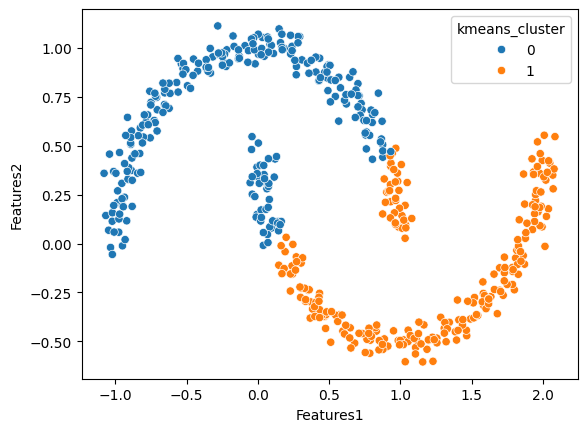

In [226]:
sns.scatterplot(x=df['Features1'],
                y=df['Features2'],
                hue=df['kmeans_cluster'],
                palette='tab10')